# **Tugas Ekstraksi Fitur - Computer Vision**
**Nama : Fadhli Ilham Nafi'an Yuswono**

**NIM : 2318001**

Import Library & connect ke Google Drive

In [1]:
import cv2
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

# Menyambungkan ke Google Drive
drive.mount('/content/drive')
print("✅ Google Drive berhasil tersambung! 📁")

Mounted at /content/drive
✅ Google Drive berhasil tersambung! 📁


Menampilkan Citra dari Google Drive

FOTO CITRA


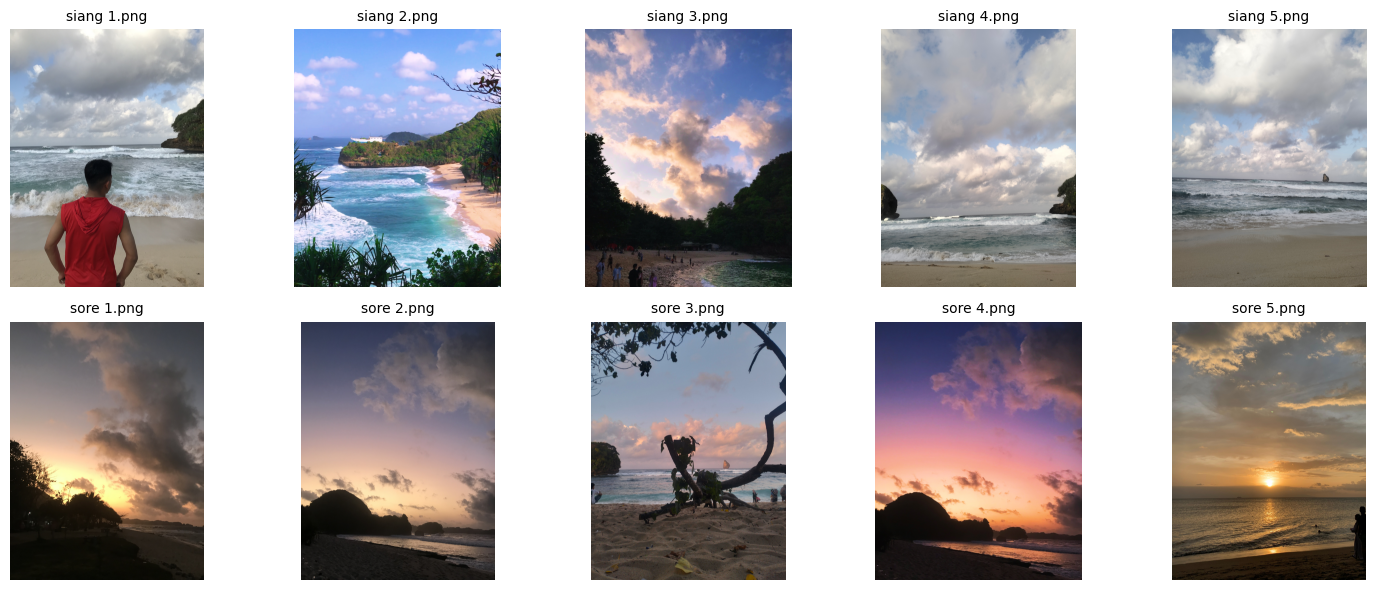

In [2]:
folder_path = '/content/drive/MyDrive/Study/Semester 6/Computer Vision/Tugas Ekstraksi Fitur/10 Citra'

plt.figure(figsize=(15, 6))
print("FOTO CITRA")

idx = 1
# u/ membaca gambar secara berurutan
for filename in sorted(os.listdir(folder_path)):
    if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
        img_path = os.path.join(folder_path, filename)
        img = cv2.imread(img_path) # read citra

        if img is not None:
            # convert BGR ke RGB agar warna normal saat ditampilkan
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            if idx <= 10:
                plt.subplot(2, 5, idx)
                plt.imshow(img_rgb)
                plt.title(filename, fontsize=10)
                plt.axis('off')
                idx += 1

plt.tight_layout()
plt.show()

Proses Ekstraksi Fitur Rata-Rata Warna RGB

In [3]:
# Buat list kosong u/ menyimpan nilai fitur warna dan nama file
features = []
image_names = []

for filename in sorted(os.listdir(folder_path)):
    if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
        img = cv2.imread(os.path.join(folder_path, filename))

        if img is not None:
            # Ekstraksi rata2 warna (Blue=0, Green=1, Red=2)
            mean_b = np.mean(img[:,:,0])
            mean_g = np.mean(img[:,:,1])
            mean_r = np.mean(img[:,:,2])

            # Gabungkan fitur warna ke dalam list
            color_feature = [mean_r, mean_g, mean_b]
            features.append(color_feature)

            # Tambahkan nama file citra ke dalam list
            image_names.append(filename)
print(f"✨Ekstraksi fitur RGB seelsai, total {len(image_names)} citra! 🎨")

✨Ekstraksi fitur RGB seelsai, total 10 citra! 🎨


Pembuatan Tabel & Export ke CSV

In [4]:
# konversi list fitur warna dan nama file citra menjadi numpy array
features = np.array(features)
image_names = np.array(image_names)

# membuat DataFrame dari numpy array fitur warna dan nama file citra
df = pd.DataFrame({
    'Nama File': image_names,
    'Mean R': features[:,0],
    'Mean G': features[:,1],
    'Mean B': features[:,2]
})

# Menghitung total kecerahan (R + G + B)
df['Total RGB'] = df['Mean R'] + df['Mean G'] + df['Mean B']

threshold = 340
df['Prediksi Waktu'] = ['Siang' if total > threshold else 'Sore' for total in df['Total RGB']]

print("HASIL TABEL EKSTRAKSI FITUR")
df.index = df.index + 1
display(df)

csv_output = '/content/drive/MyDrive/Study/Semester 6/Computer Vision/Tugas Ekstraksi Fitur/2318001FadhliHasilEktraksiFitur.csv'
df.to_csv(csv_output, index=False)
print(f"\n✅ File CSV berhasil disimpan!\n📂 Lokasi : {csv_output} 📊")

HASIL TABEL EKSTRAKSI FITUR


,Nama File,Mean R,Mean G,Mean B,Total RGB,Prediksi Waktu
1,siang 1.png,152.927553,146.505719,148.235674,447.668946,Siang
2,siang 2.png,127.132755,148.121685,176.465551,451.719991,Siang
3,siang 3.png,114.755776,111.455524,124.899714,351.111014,Siang
4,siang 4.png,158.170803,158.681885,161.007061,477.859748,Siang
5,siang 5.png,155.867306,157.542784,159.321483,472.731574,Siang
6,sore 1.png,103.376188,90.065440,78.488749,271.930378,Sore
7,sore 2.png,115.695732,101.773414,101.139016,318.608163,Sore
8,sore 3.png,109.426835,107.377966,113.039127,329.843928,Sore
9,sore 4.png,128.059140,92.137429,100.908746,321.105316,Sore
10,sore 5.png,124.382872,104.657505,81.285601,310.325978,Sore



✅ File CSV berhasil disimpan!
📂 Lokasi : /content/drive/MyDrive/Study/Semester 6/Computer Vision/Tugas Ekstraksi Fitur/2318001FadhliHasilEktraksiFitur.csv 📊
